In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/ece228_project/csi_dataset/

/content/drive/MyDrive/ece228_project/csi_dataset


In [ ]:
import os
import re
import pickle
import numpy as np
from pathlib import Path
from scipy import interpolate
import matplotlib.pyplot as plt

In [ ]:
#System Parameters
DATASET_PATH     = Path("/content/drive/MyDrive/ece228_project/csi_dataset/Manuscript_data")
NUM_PARTICIPANTS = 25
NUM_WALKS        = 40
TARGET_FS        = 48.0   # (Hz) uniform grid rate after resampling
MA_WINDOW        = 100    # samples (~2 sec). This gives the moving-average window for static removal

#Minimum packet rate (Hz) for an AP to be considered usable for Doppler sensing.
# Walking Doppler on 2.4 GHz peaks at around 24 Hz, so we need at least 2 times of that.
MIN_USABLE_RATE  = 20.0   # Hz

## CSI Parsing Process

**CSI array layout (128 signed integers per packet):**
```
[0-11]   header + lower guard band  → skip
[12-63]  subcarriers -26 to -1      → 26 complex pairs (imag, real)
[64-65]  DC null                    → skip
[66-117] subcarriers +1 to +26      → 26 complex pairs (imag, real)
[118-127] upper guard band          → skip
```
Each pair stores imaginary first, then real.


In [ ]:
def parse_csi_array(csi_str):
    """
    Parse the bracketed CSI string from column 25 into a 128-element int16 array
    Returns None for corrupted rows with missing values.
    """
    inner = csi_str.strip().strip('[]')
    if not inner:
        return None
    vals = inner.split()
    if len(vals) != 128:
        return None
    try:
        return np.array(vals, dtype=np.int16)
    except ValueError:
        return None


def extract_subcarriers(csi_arr):
    """
    Extract 52 valid complex subcarrier values from a 128-int CSI array.

    Negative freq [-26 to -1] are indices 12-63  (26 pairs)
    Positive freq [+1 to +26] areindices 66-117 (26 pairs)

    Returns complex64 array of shape (52,):
        [H_{-26}, ..., H_{-1}, H_{+1}, ..., H_{+26}]
    """
    neg = csi_arr[12:64].reshape(26, 2)    #col0=imag, col1=real for neg-freq subcarriers
    pos = csi_arr[66:118].reshape(26, 2)   #col0=imag, col1=real for pos-freq subcarriers
    H_neg = neg[:, 1].astype(np.float32) + 1j * neg[:, 0].astype(np.float32)
    H_pos = pos[:, 1].astype(np.float32) + 1j * pos[:, 0].astype(np.float32)
    return np.concatenate([H_neg, H_pos])  #shape (52,)

## Data Loading and Cleaning

In [ ]:
def find_best_mac(data_path):
    """
    Not all Participants in dataset have the same best MAC address or the fastest router, so this is done participant-wise
    Scan data file and return the MAC address with the highest packet count,
    along with a sorted list of all (MAC, count) pairs for diagnostics.

    """
    mac_counts = {}
    with open(data_path, 'r') as f:
        for line in f:
            fields = line.strip().split(',')
            if len(fields) < 3:
                continue
            mac = fields[2]
            mac_counts[mac] = mac_counts.get(mac, 0) + 1

    if not mac_counts:
        return None, []

    sorted_macs = sorted(mac_counts.items(), key=lambda x: -x[1])
    best_mac    = sorted_macs[0][0]
    return best_mac, sorted_macs


def load_participant_data(participant_id):
    """
    Load CSI data for one participant using the best available AP.

    Returns:
      best_mac:str — MAC address used
      timestamps :np.ndarray shape (N,) - unix timestamps
      csi_matrix: np.ndarray shape (N, 52) complex64 subcarrier values
    Returns (None, None, None) if no usable AP found.
    """
    data_path = (
        DATASET_PATH
        / f"Participant_{participant_id}"
        / f"participant_{participant_id}_data.csv"
    )

    best_mac, sorted_macs = find_best_mac(data_path)
    if best_mac is None:
        print(f"  P{participant_id}: WARNING — file appears empty")
        return None, None, None

    # Estimate rate of best MAC using its packet count and session duration
    # (rough check: flag if the best AP is suspiciously slow)
    best_count = sorted_macs[0][1]
    print(f"  P{participant_id}: using AP {best_mac} ({best_count} packets) "
          f"| top-3 MACs: {sorted_macs[:3]}")

    # Second pass: load CSI only for the chosen MAC
    timestamps = []
    csi_rows   = []
    n_skipped  = 0

    with open(data_path, 'r') as f:
        for line in f:
            fields = line.strip().split(',')

            if len(fields) < 27:
                n_skipped += 1
                continue

            if fields[2] != best_mac:
                continue

            arr = parse_csi_array(fields[25])
            if arr is None:
                n_skipped += 1
                continue

            csi_rows.append(extract_subcarriers(arr))
            timestamps.append(float(fields[-1]))

    if len(csi_rows) == 0:
        print(f"  P{participant_id}: WARNING — 0 valid packets after parsing")
        return None, None, None

    if n_skipped > 0:
        print(f"  P{participant_id}: {n_skipped} malformed rows skipped")

    timestamps = np.array(timestamps, dtype=np.float64)
    csi_matrix = np.stack(csi_rows, axis=0)   # (N, 52)

    order = np.argsort(timestamps)
    return best_mac, timestamps[order], csi_matrix[order]

## Walk Segmentation via Labels

Label file format:
```
AB Walk 1 stop,<ts>
AB Walk 1 start walk,<ts>   ← walking begins
AB 1 End Walk,<ts>          ← walking ends
Turnaround 1,<ts>
BA Walk 2 stop,<ts>
...
```
Active Doppler window = `start walk` → `End Walk` (~3.5–4 sec per walk).

In [ ]:
def parse_labels(participant_id):
    """
    Parse label file and return a list of (t_start, t_end) tuples for each walk and return the list sorted by walk number.

    """
    label_path = (
        DATASET_PATH
        / f"Participant_{participant_id}"
        / f"Participant_{participant_id}_labels.csv"
    )

    start_re = re.compile(r'(?:AB|BA) Walk (\d+) start walk')
    end_re   = re.compile(r'(?:AB|BA) (\d+) End Walk')

    starts, ends = {}, {}

    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Split from right to handle any commas in event descriptions
            parts = line.rsplit(',', 1)
            if len(parts) != 2:
                continue
            event, ts = parts[0], float(parts[1])

            m = start_re.search(event)
            if m:
                starts[int(m.group(1))] = ts
                continue

            m = end_re.search(event)
            if m:
                ends[int(m.group(1))] = ts

    walks = []
    for n in sorted(starts):
        if n not in ends:
            print(f"  Warning: walk {n} has no End Walk event")
            continue
        walks.append((starts[n], ends[n]))

    return walks  # list of (t_start, t_end), length should be NUM_WALKS


## Resampling and Static Multipath Removal

In [ ]:

def resample_uniform(timestamps, csi_matrix, fs=TARGET_FS):
    """
    Resample irregularly-timed CSI packets onto a uniform grid at `fs` Hz, since STFT requires
    uniform time steps for each participants time series data.

    Interpolates real and imaginary parts independently using linear interpolation.


    Returns (t_uniform, csi_resampled) or (None, None) if segment is too short.
    """
    if len(timestamps) < 4:
        return None, None

    t0, t1    = timestamps[0], timestamps[-1]
    if t1 <= t0:
        return None, None

    n_samples = max(2, int(np.floor((t1 - t0) * fs)))
    t_uniform = np.linspace(t0, t1, n_samples)

    n_sub = csi_matrix.shape[1]
    csi_resampled = np.zeros((n_samples, n_sub), dtype=np.complex64)

    for k in range(n_sub):
        re_vals = csi_matrix[:, k].real.astype(np.float64)
        im_vals = csi_matrix[:, k].imag.astype(np.float64)

        re_interp = interpolate.interp1d(
            timestamps, re_vals, kind='linear',
            bounds_error=False,
            fill_value=(re_vals[0], re_vals[-1])
        )
        im_interp = interpolate.interp1d(
            timestamps, im_vals, kind='linear',
            bounds_error=False,
            fill_value=(im_vals[0], im_vals[-1])
        )
        csi_resampled[:, k] = re_interp(t_uniform) + 1j * im_interp(t_uniform)

    # replace any residual NaN/inf with 0 before returning
    csi_resampled = np.nan_to_num(csi_resampled, nan=0.0, posinf=0.0, neginf=0.0)

    return t_uniform, csi_resampled


def remove_static(csi_matrix, window=MA_WINDOW):
    """
    Subtract a moving average from each subcarrier's time series to remove
    the static multipath component, leaving only the dynamic Doppler signal.

    """
    n_samples     = csi_matrix.shape[0]
    actual_window = min(window, n_samples)
    kernel = np.ones(actual_window, dtype=np.float32) / actual_window
    out    = np.zeros_like(csi_matrix)

    for k in range(csi_matrix.shape[1]):
        ma_real = np.convolve(csi_matrix[:, k].real, kernel, mode='same')
        ma_imag = np.convolve(csi_matrix[:, k].imag, kernel, mode='same')
        out[:, k] = (csi_matrix[:, k].real - ma_real) + 1j * (csi_matrix[:, k].imag - ma_imag)

    return out

## Full Pipeline — Process All Participants

In [ ]:
def process_all_participants():
    """
    Run the full preprocessing pipeline for all 25 participants.
    For each walk segment, load dataset and extract labels and does all processing upto static multipath removal

    Returns a list of dicts, one per valid walk segment:
      'participant' : int  1-25
      'walk'        : int  1-40
      'label'       : int  0-24  (participant_id - 1, for classification)
      'ap_mac'      : str  —MAC address used for this participant
      'csi'         : np.ndarray (T, 52) complex64  — cleaned CSI time series
      'fs'          : float  TARGET_FS
    """
    dataset              = []
    skipped_participants = []
    ap_log               = {}   # pid → MAC used, for post-hoc inspection

    for pid in range(1, NUM_PARTICIPANTS + 1):
        print(f"Processing Participant {pid}...")

        best_mac, timestamps, csi_matrix = load_participant_data(pid)

        if timestamps is None:
            print(f"  -> Skipping Participant {pid} entirely")
            skipped_participants.append(pid)
            continue

        ap_log[pid] = best_mac
        walks = parse_labels(pid)

        if len(walks) != NUM_WALKS:
            print(f"  WARNING: expected {NUM_WALKS} walks, got {len(walks)}")

        n_ok = 0
        for walk_idx, (t_start, t_end) in enumerate(walks):
            walk_num = walk_idx + 1

            mask    = (timestamps >= t_start) & (timestamps <= t_end)
            t_seg   = timestamps[mask]
            csi_seg = csi_matrix[mask]

            if len(t_seg) < 4:
                print(f"  WARNING: P{pid} walk {walk_num} — only {len(t_seg)} packets, skipping")
                continue

            t_uni, csi_uni = resample_uniform(t_seg, csi_seg)
            if t_uni is None:
                print(f"  WARNING: P{pid} walk {walk_num} — resampling failed, skipping")
                continue

            csi_clean = remove_static(csi_uni)

            dataset.append({
                'participant': pid,
                'walk':        walk_num,
                'label':       pid - 1,
                'ap_mac':      best_mac,
                'csi':         csi_clean,
                'fs':          TARGET_FS,
            })
            n_ok += 1

        print(f"  -> {n_ok}/{len(walks)} walks processed successfully")

    print(f"\nTotal samples: {len(dataset)}  (expected {NUM_PARTICIPANTS * NUM_WALKS})")

    if skipped_participants:
        print(f"Participants skipped: {skipped_participants}")

    print(f"\nAP used per participant:")
    for pid, mac in sorted(ap_log.items()):
        print(f"  P{pid:2d}: {mac}")

    return dataset, ap_log


dataset, ap_log = process_all_participants()

Processing Participant 1...
  P1: using AP 30:C6:F7:43:33:00 (24797 packets) | top-3 MACs: [('30:C6:F7:43:33:00', 24797), ('7C:87:CE:CB:4B:C0', 21829), ('08:D1:F9:D1:1D:9C', 16978)]
  P1: 2 malformed rows skipped
  -> 40/40 walks processed successfully
Processing Participant 2...
  P2: using AP 48:E7:29:B4:ED:6C (24359 packets) | top-3 MACs: [('48:E7:29:B4:ED:6C', 24359), ('08:D1:F9:D1:1D:9C', 20211), ('48:E7:29:AF:A9:AC', 15983)]
  P2: 2 malformed rows skipped
  -> 38/40 walks processed successfully
Processing Participant 3...
  P3: using AP B0:A7:32:2A:3E:08 (23925 packets) | top-3 MACs: [('B0:A7:32:2A:3E:08', 23925), ('08:D1:F9:D1:1D:9C', 22312), ('48:E7:29:95:A1:78', 16774)]
  -> 39/40 walks processed successfully
Processing Participant 4...
  P4: using AP 48:E7:29:B6:DF:E4 (25106 packets) | top-3 MACs: [('48:E7:29:B6:DF:E4', 25106), ('48:E7:29:AF:9A:8C', 24741), ('48:E7:29:B4:ED:6C', 22292)]
  P4: 3 malformed rows skipped
  -> 40/40 walks processed successfully
Processing Particip

In [ ]:
sample = dataset[0]
T, S = sample['csi'].shape
print(f"Participant: {sample['participant']}  Walk: {sample['walk']}  Label: {sample['label']}")
print(f"CSI shape:   ({T}, {S})  →  {T/sample['fs']:.2f} sec  x  {S} subcarriers")

# Check label distribution
from collections import Counter
label_counts = Counter(s['label'] for s in dataset)
walks_per_participant = [label_counts[i] for i in range(NUM_PARTICIPANTS)]
print(f"\nWalks per participant — min: {min(walks_per_participant)}, max: {max(walks_per_participant)}")
print(f"Participants with all 40 walks: {sum(1 for c in walks_per_participant if c == NUM_WALKS)}/25")

Participant: 1  Walk: 1  Label: 0
CSI shape:   (174, 52)  →  3.62 sec  x  52 subcarriers

Walks per participant — min: 35, max: 40
Participants with all 40 walks: 15/25


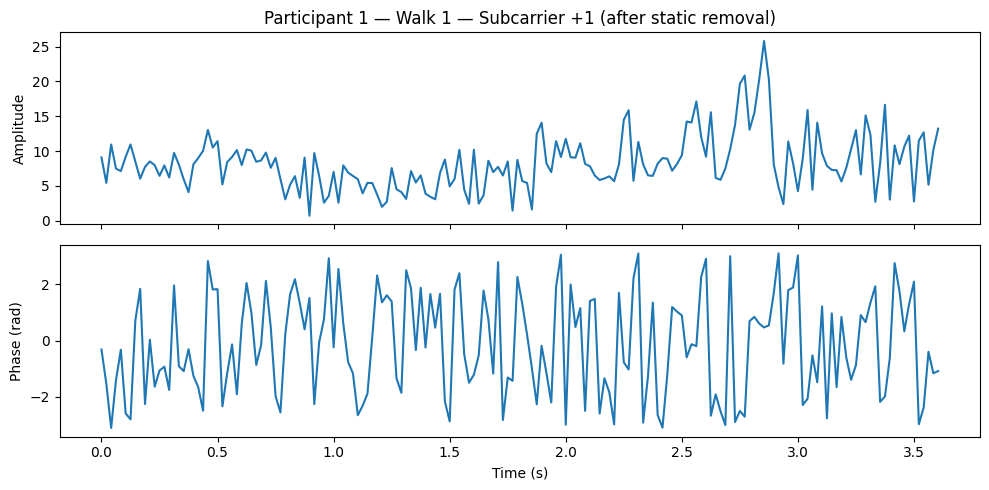

In [ ]:
# Plot amplitude and phase of one subcarrier for Walk 1, Participant 1
csi = dataset[0]['csi']         # shape (T, 52)
fs  = dataset[0]['fs']
t   = np.arange(csi.shape[0]) / fs
sub = 26                         # subcarrier index 26 = first positive-freq subcarrier (+1)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, np.abs(csi[:, sub]))
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Participant 1 — Walk 1 — Subcarrier +1 (after static removal)")
axes[1].plot(t, np.angle(csi[:, sub]))
axes[1].set_ylabel("Phase (rad)")
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [ ]:
save_path = Path("/content/drive/MyDrive/ece228_project/csi_dataset/processed_dataset_nanguard.pkl")
with open(save_path, 'wb') as f:
    pickle.dump(dataset, f)
print(f"Saved {len(dataset)} samples to {save_path}")


Saved 975 samples to /content/drive/MyDrive/ece228_project/csi_dataset/processed_dataset_nanguard.pkl


---
## Spectrogram Generation

Convert each cleaned CSI segment (T × 52 complex) into a fixed-size 2D Doppler-time spectrogram image.

**Pipeline per segment:**
1. Average `|H[t,k]|` across all 52 subcarriers → 1D amplitude signal `(T,)`
2. STFT along the time axis → 2D time-frequency matrix
3. Convert to dB scale
4. Resize to fixed `(64 × 64)` pixels
5. Per-image z-score normalisation

In [ ]:
import pickle
import numpy as np
from pathlib import Path
from scipy.signal import stft
from skimage.transform import resize
import matplotlib.pyplot as plt

# Load the processed dataset saved in the previous stage
with open(Path("/content/drive/MyDrive/ece228_project/csi_dataset/processed_dataset_nanguard.pkl"), 'rb') as f:
    dataset = pickle.load(f)

# dataset = saved['dataset']
# ap_log  = saved['ap_log']

print(f"Loaded {len(dataset)} walk segments")
print(f"Sample entry keys: {list(dataset[0].keys())}")

Loaded 975 walk segments
Sample entry keys: ['participant', 'walk', 'label', 'ap_mac', 'csi', 'fs']


In [ ]:
# ── Spectrogram configuration ──────────────────────────────────────────────────
IMG_H    = 64    # output image height (frequency axis)
IMG_W    = 64    # output image width  (time axis)

# STFT parameters
# nperseg=32 at 48 Hz → each frame covers ~0.67 sec, freq resolution = 1.5 Hz/bin
# noverlap=24 → hop of 8 samples (~0.17 sec), giving good time resolution
# nfft=64     → zero-padded to 64, freq resolution = 48/64 = 0.75 Hz/bin after padding
NPERSEG  = 32
NOVERLAP = 24    # hop = NPERSEG - NOVERLAP = 8 samples
NFFT     = 64


def make_spectrogram(csi, fs, nperseg=NPERSEG, noverlap=NOVERLAP, nfft=NFFT,
                     img_h=IMG_H, img_w=IMG_W):
    """
    Generate a Doppler-time spectrogram image from one cleaned CSI segment.

    Args:
        csi : np.ndarray (T, 52) complex64 — cleaned CSI time series
        fs  : float — sample rate (TARGET_FS = 48 Hz)

    Returns:
        np.ndarray (img_h, img_w) float32 — z-score normalised spectrogram image
    """
    # 1. Average magnitude across 52 subcarriers → 1D real signal
    amplitude = np.abs(csi).mean(axis=1)   # (T,)

    # Guard: sanitise any NaN/inf that survived from upstream processing
    amplitude = np.nan_to_num(amplitude, nan=0.0, posinf=0.0, neginf=0.0)

    # 2. Zero-pad if the segment is shorter than the STFT window
    if len(amplitude) < nperseg:
        amplitude = np.pad(amplitude, (0, nperseg - len(amplitude)), mode='constant')

    # 3. STFT — returns one-sided spectrum (real input), shape (nfft//2+1, n_frames)
    _, _, Zxx = stft(amplitude, fs=fs, nperseg=nperseg, noverlap=noverlap,
                     nfft=nfft, boundary='zeros')

    # 4. Power spectrogram in dB
    spec = 20.0 * np.log10(np.abs(Zxx) + 1e-6)

    # 5. Resize to fixed shape (freq × time)
    spec = resize(spec, (img_h, img_w), anti_aliasing=True, mode='reflect')

    # 6. Per-image z-score normalisation
    std = spec.std()
    spec = (spec - spec.mean()) / (std if std > 1e-8 else 1.0)

    return spec.astype(np.float32)

In [ ]:
N = len(dataset)

spectrograms = np.zeros((N, IMG_H, IMG_W), dtype=np.float32)
labels       = np.zeros(N, dtype=np.int64)
participants = np.zeros(N, dtype=np.int64)
walks        = np.zeros(N, dtype=np.int64)

for i, entry in enumerate(dataset):
    spectrograms[i] = make_spectrogram(entry['csi'], fs=entry['fs'])
    labels[i]       = entry['label']
    participants[i] = entry['participant']
    walks[i]        = entry['walk']

    if (i + 1) % 100 == 0 or (i + 1) == N:
        print(f"  {i+1}/{N} spectrograms generated")

print(f"\nDone.")
print(f"spectrograms : {spectrograms.shape}  dtype={spectrograms.dtype}")
print(f"labels       : {labels.shape}        unique={np.unique(labels)}")
print(f"Value range  : [{spectrograms.min():.3f}, {spectrograms.max():.3f}]")

  100/975 spectrograms generated
  200/975 spectrograms generated
  300/975 spectrograms generated
  400/975 spectrograms generated
  500/975 spectrograms generated
  600/975 spectrograms generated
  700/975 spectrograms generated
  800/975 spectrograms generated
  900/975 spectrograms generated
  975/975 spectrograms generated

Done.
spectrograms : (975, 64, 64)  dtype=float32
labels       : (975,)        unique=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Value range  : [-7.500, 3.500]


In [ ]:
print(f"label       :{labels[0]} ")
print(f"participant        :{participants[2]} ")

label       :0 
participant        :1 


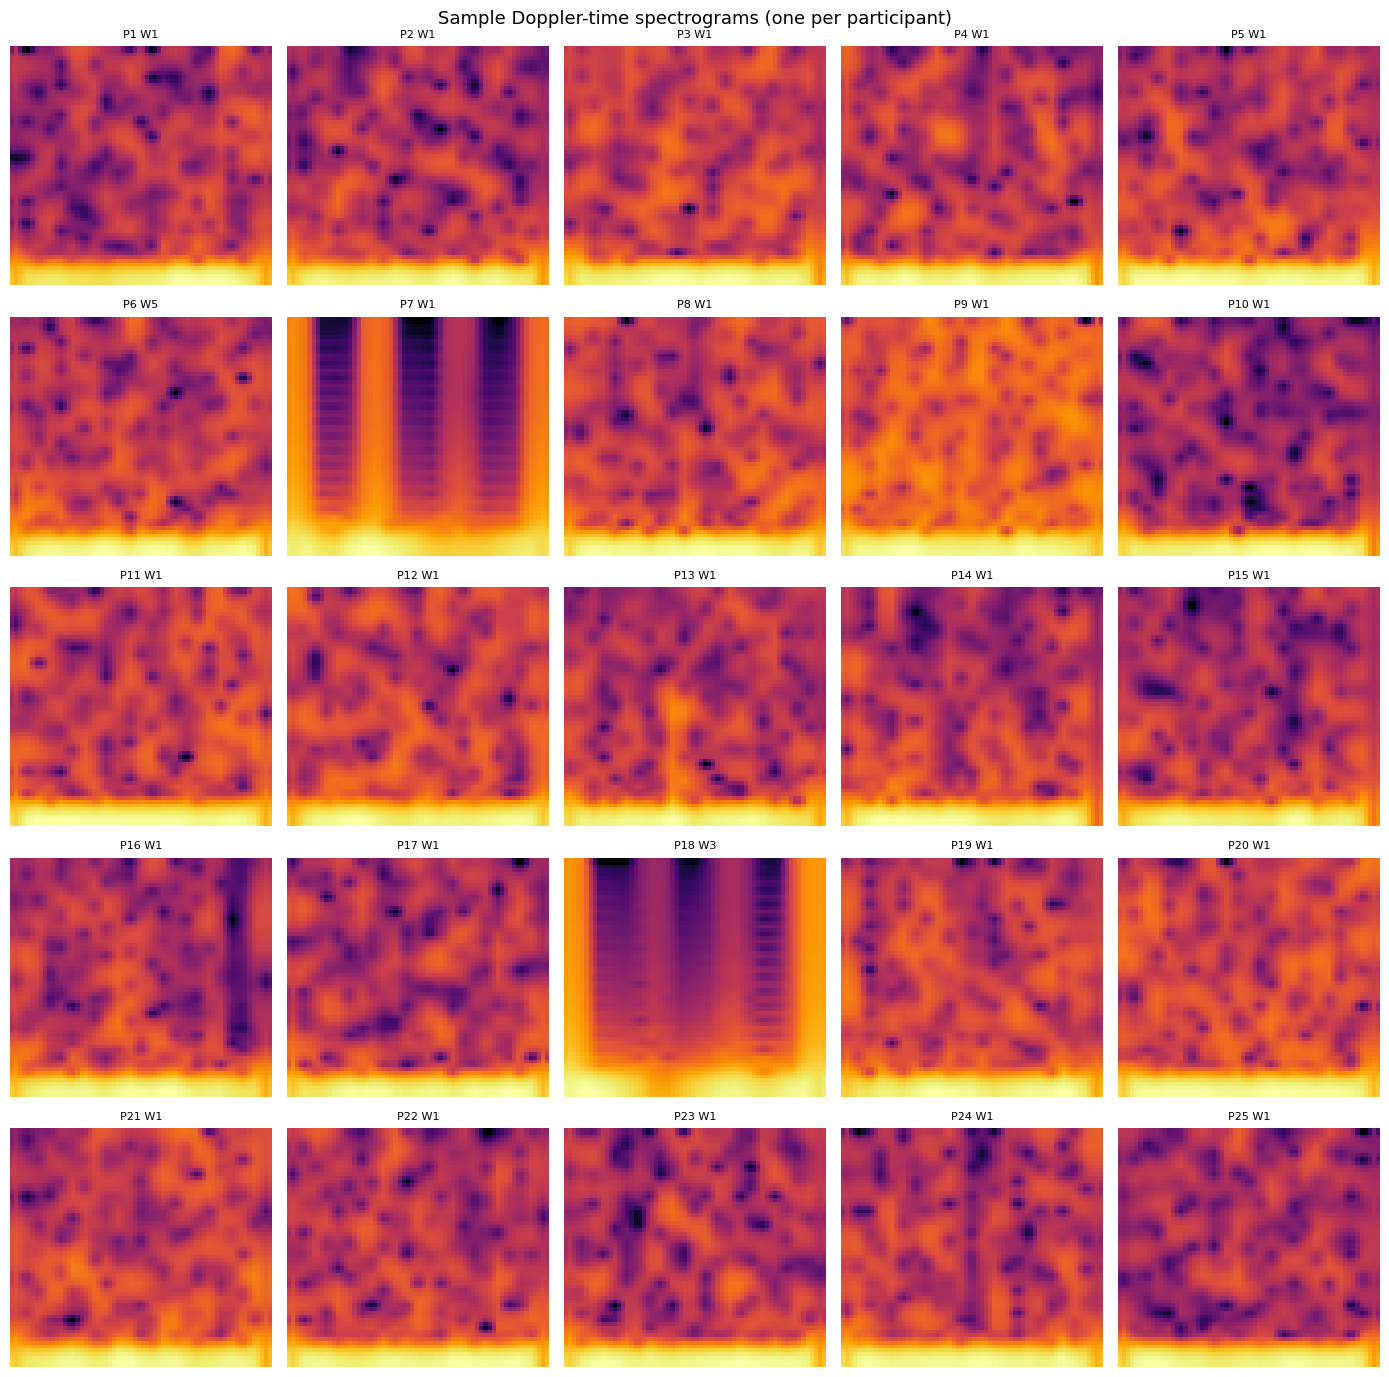

In [ ]:
# ── Visualise: one spectrogram per participant (walk 1), 5 × 5 grid ────────────
fig, axes = plt.subplots(5, 5, figsize=(14, 14))
axes = axes.flatten()

shown = {}   # pid → index into spectrograms array
for i, pid in enumerate(participants):
    if pid not in shown:
        shown[pid] = i
    if len(shown) == 25:
        break

for ax_idx, (pid, i) in enumerate(sorted(shown.items())):
    ax = axes[ax_idx]
    ax.imshow(spectrograms[i], aspect='auto', origin='lower', cmap='inferno')
    ax.set_title(f"P{pid} W{walks[i]}", fontsize=8)
    ax.axis('off')

plt.suptitle("Sample Doppler-time spectrograms (one per participant)", fontsize=13)
plt.tight_layout()
plt.show()

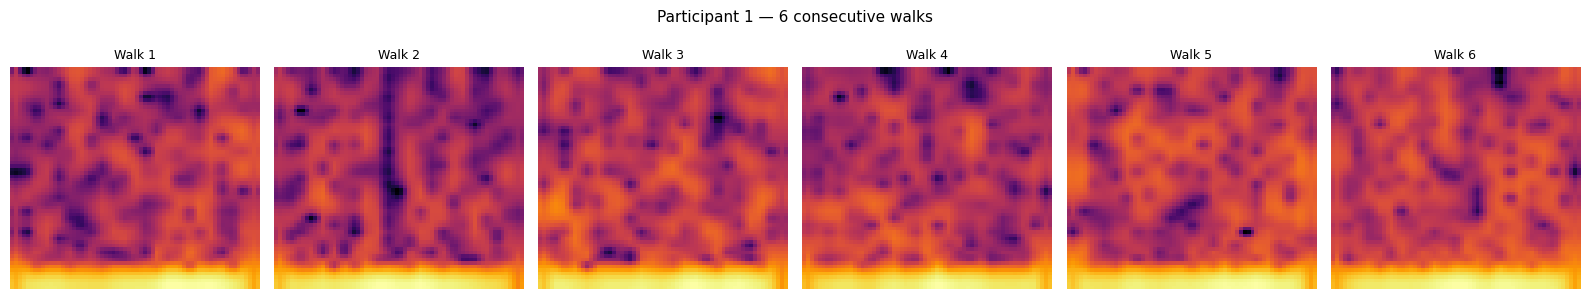

In [ ]:
# ── Visualise: 6 walks from participant 1, side by side ───────────────────────
p1_indices = [i for i, p in enumerate(participants) if p == 1][:6]
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for ax, idx in zip(axes, p1_indices):
    ax.imshow(spectrograms[idx], aspect='auto', origin='lower', cmap='inferno')
    ax.set_title(f"Walk {walks[idx]}", fontsize=9)
    ax.axis('off')
plt.suptitle("Participant 1 — 6 consecutive walks", fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Save as compressed numpy archive — much faster to reload than pickle for arrays
save_path = Path("/content/drive/MyDrive/ece228_project/csi_dataset/spectrograms1.npz")
np.savez_compressed(
    save_path,
    spectrograms=spectrograms,   # (975, 64, 64) float32
    labels=labels,               # (975,) int64  — 0-indexed participant ID
    participants=participants,   # (975,) int64  — 1-indexed participant number
    walks=walks,                 # (975,) int64  — walk number 1-40
)
print(f"Saved to {save_path}")
print(f"  spectrograms : {spectrograms.shape}  {spectrograms.nbytes / 1e6:.1f} MB")

# Quick reload test
check = np.load(save_path)
assert check['spectrograms'].shape == spectrograms.shape
print("Reload check passed.")

Saved to /content/drive/MyDrive/ece228_project/csi_dataset/spectrograms1.npz
  spectrograms : (975, 64, 64)  16.0 MB
Reload check passed.
